In [1]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torch
from pose_encoder.advanced_pose_encoder import AdvancedPoseEncoder
from dataset.dataset import *
from utils.animation.skeleton import Skeleton
import utils.utils as utils
import matplotlib.pyplot as plt
import time

In [2]:
def debug_ik_chain_rotations(pose_encoder, original_pose):
    """
    Debug function to compare IK chain rotation matrices before and after encoding/decoding.
    
    Args:
        pose_encoder: The AdvancedPoseEncoder instance
        original_pose: The original pose tensor [batch_size, pose_dim]
    """
    from utils.utils import convert_6d_to_matrix
    import numpy as np
    
    print("\n=== IK CHAIN ROTATION DEBUG ===")
    
    # Extract original rotations for each IK chain
    for name, comp in pose_encoder.components.items():
        if comp['type'] == 'ik':
            print(f"\n📊 Chain: {name}")
            
            chain_info = comp['chain_info']
            joint_indices = comp['joint_indices']
            
            if len(joint_indices) < 12:
                print(f"  ⚠️ Warning: Not enough indices for chain {name}")
                continue
            
            # Get original rotations
            joint1_indices = joint_indices[:6]
            joint2_indices = joint_indices[6:12]
            
            joint1_rot_6d = original_pose[:, joint1_indices]
            joint2_rot_6d = original_pose[:, joint2_indices]
            
            # Print original rotations
            print(f"  Original Joint 1 (6D): {joint1_rot_6d.squeeze().cpu().numpy().round(3)}")
            print(f"  Original Joint 2 (6D): {joint2_rot_6d.squeeze().cpu().numpy().round(3)}")
            
            # Encode and decode
            with torch.no_grad():
                encoded_pose = pose_encoder.encode(original_pose)
                decoded_pose, _, _ = pose_encoder.decode(encoded_pose)
            
            # Get decoded rotations
            joint1_rot_6d_decoded = decoded_pose[:, joint1_indices]
            joint2_rot_6d_decoded = decoded_pose[:, joint2_indices]
            
            # Print decoded rotations
            print(f"  Decoded Joint 1 (6D): {joint1_rot_6d_decoded.squeeze().cpu().numpy().round(3)}")
            print(f"  Decoded Joint 2 (6D): {joint2_rot_6d_decoded.squeeze().cpu().numpy().round(3)}")
            
            # Calculate differences
            joint1_diff = torch.norm(joint1_rot_6d - joint1_rot_6d_decoded).item()
            joint2_diff = torch.norm(joint2_rot_6d - joint2_rot_6d_decoded).item()
            print(f"  Difference Joint 1: {joint1_diff:.4f}")
            print(f"  Difference Joint 2: {joint2_diff:.4f}")
            
            # Check if joints are orthogonal (valid rotations)
            joint1_matrix = convert_6d_to_matrix(joint1_rot_6d.unsqueeze(0)).squeeze(0)
            joint2_matrix = convert_6d_to_matrix(joint2_rot_6d.unsqueeze(0)).squeeze(0)
            joint1_matrix_decoded = convert_6d_to_matrix(joint1_rot_6d_decoded.unsqueeze(0)).squeeze(0)
            joint2_matrix_decoded = convert_6d_to_matrix(joint2_rot_6d_decoded.unsqueeze(0)).squeeze(0)
            
            # Check orthogonality by dot products of columns
            def check_orthogonality(matrix):
                x_col = matrix[0, :, 0]
                y_col = matrix[0, :, 1]
                z_col = matrix[0, :, 2]
                xy_dot = torch.dot(x_col, y_col).item()
                xz_dot = torch.dot(x_col, z_col).item()
                yz_dot = torch.dot(y_col, z_col).item()
                return abs(xy_dot) < 1e-5 and abs(xz_dot) < 1e-5 and abs(yz_dot) < 1e-5
            
            print(f"  Original rotations orthogonal: {check_orthogonality(joint1_matrix)}, {check_orthogonality(joint2_matrix)}")
            print(f"  Decoded rotations orthogonal: {check_orthogonality(joint1_matrix_decoded)}, {check_orthogonality(joint2_matrix_decoded)}")
            
            # Extract IK parameters from latent space
            ik_start_idx = 0
            for c_name, c in pose_encoder.components.items():
                if c_name == name:
                    break
                if c['type'] == 'preserve':
                    ik_start_idx += c['dim']
                elif c['type'] == 'ik':
                    ik_start_idx += 4  # 3 for position + 1 for swivel
                elif c['type'] == 'encode':
                    ik_start_idx += c['z_dim']
            
            # Get position and swivel from latent
            target_pos = encoded_pose[0, ik_start_idx:ik_start_idx+3].cpu().numpy()
            swivel = encoded_pose[0, ik_start_idx+3:ik_start_idx+4].cpu().numpy()
            print(f"  Encoded target position: {target_pos.round(3)}")
            print(f"  Encoded swivel: {swivel.round(3)}")
            
            # Compare world positions
            world_pos_original = pose_encoder.skeleton.calculate_world_positions(original_pose)
            world_pos_decoded = pose_encoder.skeleton.calculate_world_positions(decoded_pose)
            

            # In debug_ik_chain_rotations function, add this after getting the encoded pose:
            # Check for NaN values in encoded pose
            nan_mask = torch.isnan(encoded_pose)
            if nan_mask.any():
                nan_indices = torch.nonzero(nan_mask)
                print(f"  ⚠️ NaN values in encoded pose at indices: {nan_indices[:5]}")

            # Check for NaN values in decoded pose
            nan_mask = torch.isnan(decoded_pose)
            if nan_mask.any():
                nan_indices = torch.nonzero(nan_mask)
                print(f"  ⚠️ NaN values in decoded pose at indices: {nan_indices[:5]}")

            # Try to get joint indices in world positions
            try:
                joint_map = pose_encoder.joint_name_to_world_pos_idx
                start_joint = chain_info['chain_joints'][0]
                mid_joint = chain_info['chain_joints'][1]
                end_joint = chain_info['end_effector']
                
                if start_joint in joint_map and mid_joint in joint_map and end_joint in joint_map:
                    start_idx = joint_map[start_joint]
                    mid_idx = joint_map[mid_joint]
                    end_idx = joint_map[end_joint]
                    
                    # Reshape world positions
                    num_joints = len(pose_encoder.joint_name_to_world_pos_idx)
                    world_orig = world_pos_original.reshape(-1, num_joints, 3)
                    world_dec = world_pos_decoded.reshape(-1, num_joints, 3)
                    
                    # Extract relevant positions
                    orig_end_pos = world_orig[0, end_idx].cpu().numpy()
                    orig_start_pos = world_orig[0, start_idx].cpu().numpy()
                    dec_end_pos = world_dec[0, end_idx].cpu().numpy()

                    print(f"  Original end effector world pos: {orig_end_pos.round(3)}")
                    print(f"  Decoded end effector world pos: {dec_end_pos.round(3)}")

                    # Print raw decoded joint positions for debugging
                    dec_start_pos = world_dec[0, start_idx].cpu().numpy()
                    dec_mid_pos = world_dec[0, mid_idx].cpu().numpy()
                    print(f"  Decoded start pos: {dec_start_pos.round(3)}")
                    print(f"  Decoded mid pos: {dec_mid_pos.round(3)}")
                    
                    # Calculate end effector relative position
                    rel_end_pos = orig_end_pos - orig_start_pos
                    
                    print(f"  Original end effector relative pos: {rel_end_pos.round(3)}")
                    print(f"  End effector position error: {np.linalg.norm(rel_end_pos - target_pos):.4f}")
                    
                    # Compare original vs decoded end position
                    end_pos_diff = np.linalg.norm(orig_end_pos - dec_end_pos)
                    print(f"  End effector world position diff: {end_pos_diff:.4f}")
            except Exception as e:
                print(f"  ⚠️ Error getting world positions: {e}")
    
    return decoded_pose  # Return for visualization

In [ ]:
dataset = GPUDataset(
    consolidated_file="dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
    seq_length=2000, # For testing
    seed_length=0,
    batch_size=1,
    epoch_length=1,  # Set to 1 for testing purposes
    return_audio_frame_index=True,  # Set to True to return the audio frame index
)

pose_encoder_test = AdvancedPoseEncoder(
    pose_dim=345,
    component_definitions = {
        # Preserved (no encoding/decoding)
        'world_pos': {
            'bone_names': ['body_world'],
            'type': 'preserve',
            'use_position': True
        },
        'left_hand_rot': {
            'bone_names': ['b_l_wrist'],
            'type': 'preserve',
            'use_position': False
        },
        'right_hand_rot': {
            'bone_names': ['b_r_wrist'],
            'type': 'preserve',
            'use_position': False
        },
        'left_foot_rot': {
            'bone_names': ['b_l_foot'],
            'type': 'preserve',
            'use_position': False
        },
        'right_foot_rot': {
            'bone_names': ['b_r_foot'],
            'type': 'preserve',
            'use_position': False
        },        
        # Auto-encoded components - explicit bone lists
        'spine_shoulders_head': {
            'bone_names': [
                'b_root', 'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3',
                'b_l_shoulder', 'b_r_shoulder', 'b_neck0', 'b_head'
            ],
            'type': 'preserve',
            'z_dim': 9
        },
        'left_hand_fingers': {
            'bone_names': [
                # Left thumb
                'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3',
                # Left fingers  
                'b_l_index1', 'b_l_index2', 'b_l_index3',
                'b_l_middle1', 'b_l_middle2', 'b_l_middle3',
                'b_l_ring1', 'b_l_ring2', 'b_l_ring3',
                'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3'
            ],
            'type': 'preserve',
            'z_dim': 18
        },
        'right_hand_fingers': {
            'bone_names': [
                # Right thumb
                'b_r_thumb0', 'b_r_thumb1', 'b_r_thumb2', 'b_r_thumb3',
                # Right fingers
                'b_r_index1', 'b_r_index2', 'b_r_index3',
                'b_r_middle1', 'b_r_middle2', 'b_r_middle3',
                'b_r_ring1', 'b_r_ring2', 'b_r_ring3',
                'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3'
            ],
            'type': 'preserve',
            'z_dim': 18
        },
        # IK components - using skeleton's enhanced chain info
        'left_arm_ik': {
            'type': 'ik',
            'chain_joints': ['b_l_arm', 'b_l_forearm'],
            'end_effector': 'b_l_wrist',
            'z_dim': 4,  # 3 for target position + 1 swivel rotation
            'twist_joint': 'b_l_arm_twist',
            'chain_parent': 'b_l_shoulder',
            'bone1_forward_dir': [0.9993694424629211, -0.023177823051810265, -0.026897454634308815],
            'bone1_up_dir': [-0.02316943369805813, -0.9997313618659973, 0.0006235920009203255],
            'bone2_forward_dir': [0.9993695020675659, -0.02317732758820057, -0.026897458359599113],
            'bone2_up_dir': [-0.023168936371803284, -0.9997313618659973, 0.0006235786713659763],
        },
        'right_arm_ik': {
            'type': 'ik',
            'chain_joints': ['b_r_arm', 'b_r_forearm'],
            'end_effector': 'b_r_wrist',
            'z_dim': 4,
            'twist_joint': 'b_r_arm_twist',
            'chain_parent': 'b_r_shoulder',
            'bone1_forward_dir': [-0.9992618560791016, -0.028031472116708755, -0.026267891749739647],
            'bone1_up_dir': [0.02802179381251335, -0.9996070861816406, 0.0007366171339526772],
            'bone2_forward_dir': [-0.9992617964744568, -0.028031865134835243, -0.02626790478825569],
            'bone2_up_dir': [0.02802218683063984, -0.9996070265769958, 0.0007366279023699462],
        },
        'left_leg_ik': {
            'type': 'ik',
            'chain_joints': ['b_l_upleg', 'b_l_leg'],
            'end_effector': 'b_l_foot',
            'z_dim': 4,
            'chain_parent': 'b_root',
            'bone1_forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097],
            'bone1_up_dir': [0.0, 0.007038275711238384, 0.9999752640724182],
            'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420658826828],
            'bone2_up_dir': [0.0, 0.0801420658826828, -0.996783435344696],
        },
        'right_leg_ik': {
            'type': 'ik',
            'chain_joints': ['b_r_upleg', 'b_r_leg'],
            'end_effector': 'b_r_foot',
            'z_dim': 4,
            'chain_parent': 'b_root',
            'bone1_forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361],
            'bone1_up_dir': [0.0, 0.0043573565781116486, 0.9999905228614807],
            'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420733332634],
            'bone2_up_dir': [0.0, 0.0801420733332634, -0.996783435344696],
        }
    },
    skeleton = dataset.skeleton,
    device = utils.get_device()
)

Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/toy/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([49628, 345]), Audio shape: torch.Size([49628, 37])
Found 28416 valid starting points for windows
Dataset initialization complete!

Unhandled bones that will use identity rotation:
  b_r_arm_twist: indices 57-62
  b_r_wrist_twist: indices 69-74
  b_l_arm_twist: indices 189-194
  b_l_wrist_twist: indices 201-206

=== Pose Encoder Component Information ===

world_pos (preserve):
  Indices: [0, 1, 2]
  Dimensions: 3

left_hand_rot (preserve):
  Indices: [207, 208, 209, 210, 211, 212]
  Dimensions: 6

right_hand_rot (preserve):
  Indices: [75, 76, 77, 78, 79, 80]
  Dimensions: 6

left_foot_rot (preserve):
  Indices: [339, 340, 341, 342, 343, 344]
  Dimensions: 6

right_foot_rot (preserve):
  Indices: [321, 322, 323, 324, 325, 326]
  Dimensions: 6

spine_shoulders_head (preserve):
  Indices: [3, 4, 5, 6, 7, 8, 

In [4]:
# Import the viewer
import utils.animation.visualisation.new.animation_visualisation as animation_visualisation
animation_visualisation.init_visualization()
time.sleep(1)  # Wait for the visualization to initialize
animation_visualisation.send_character("ground_truth", (0.0,0.0,0.0), 0, "red")

Viewer URL: http://localhost:8000/utils/animation/visualisation/new/animation_viewer2.html?wsport=8700


TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
ik reconstructed elbow positions: tensor([[-22.7674, 114.7247,  -6.4884]], device='cuda:0')
ik reconstructed target positions: tensor([[-25.1156, 116.0460,  20.1834]], device='cuda:0')


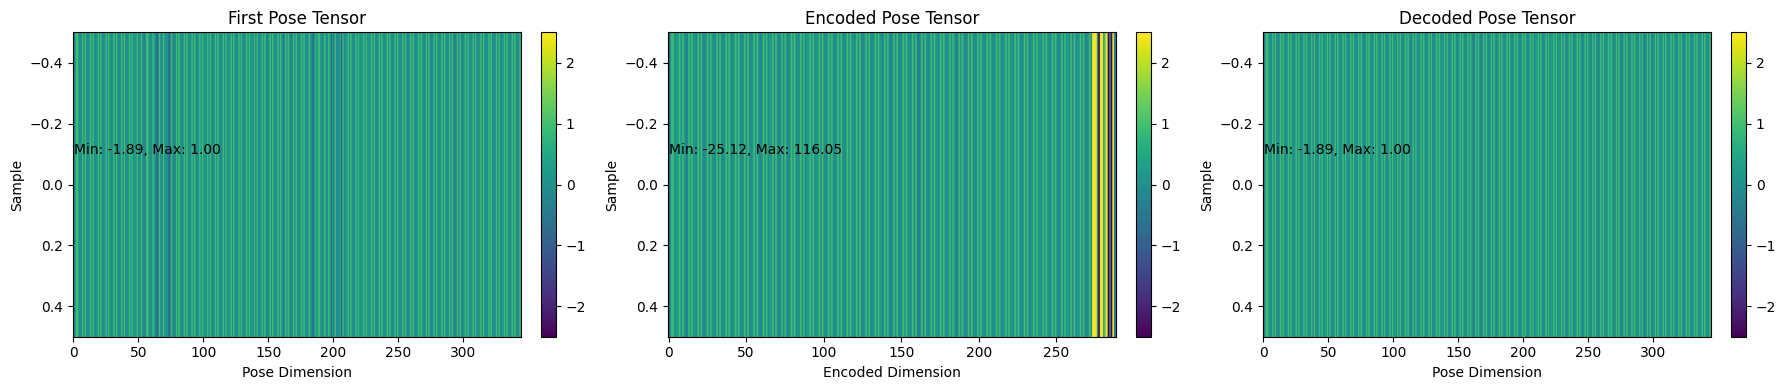

In [20]:
dataset.reshuffle()

with torch.no_grad():
    # Get a sample from the dataset
    # gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, full_audio_features, start_frame, file = next(iter(dataset))
    gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, start_frames = next(iter(dataset))

    skeleton: Skeleton = dataset.skeleton

    gesture_sequence = skeleton.denormalize_poses(gesture_sequence)

    # Extract the first pose from the sequence
    first_pose = gesture_sequence.squeeze(0)[0]  # Get the first pose tensor

    # Create a copy of the first pose with batch dimension
    test_pose = first_pose.unsqueeze(0).float()

    # Run debug function
    # decoded_debug = debug_ik_chain_rotations(pose_encoder_test, test_pose)


    # Encode the first pose
    encoded_pose = pose_encoder_test.encode(test_pose)

    # Decode the encoded pose back to the original pose space
    decoded_pose, pre_ik_output, type_mask, ik_reconstructed_elbow_pos, ik_reconstructed_target_pos = pose_encoder_test.decode(encoded_pose)

    print("ik reconstructed elbow positions:", ik_reconstructed_elbow_pos)
    print("ik reconstructed target positions:", ik_reconstructed_target_pos)

    show = True

    if show:
        fig, axs = plt.subplots(1, 3, figsize=(18, 4))

        # First pose
        im0 = axs[0].imshow(first_pose.cpu().numpy().reshape(1, -1), aspect='auto', cmap='viridis', vmin=-2.5, vmax=2.5)
        axs[0].set_title("First Pose Tensor")
        axs[0].set_xlabel("Pose Dimension")
        axs[0].set_ylabel("Sample")
        # write the min and max values of the pose tensor
        axs[0].text(0.5, -0.1, f"Min: {first_pose.min().item():.2f}, Max: {first_pose.max().item():.2f}")
        plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

        # Encoded pose
        im1 = axs[1].imshow(encoded_pose.cpu().numpy().reshape(1, -1), aspect='auto', cmap='viridis', vmin=-2.5, vmax=2.5)
        axs[1].set_title("Encoded Pose Tensor")
        axs[1].set_xlabel("Encoded Dimension")
        axs[1].set_ylabel("Sample")
        # write the min and max values of the encoded pose tensor
        axs[1].text(0.5, -0.1, f"Min: {encoded_pose.min().item():.2f}, Max: {encoded_pose.max().item():.2f}")
        plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

        # Decoded pose
        im2 = axs[2].imshow(pre_ik_output.cpu().numpy().reshape(1, -1), aspect='auto', cmap='viridis', vmin=-2.5, vmax=2.5)
        axs[2].set_title("Decoded Pose Tensor")
        axs[2].set_xlabel("Pose Dimension")

        axs[2].set_ylabel("Sample")
        # write the min and max values of the decoded pose tensor
        axs[2].text(0.5, -0.1, f"Min: {pre_ik_output.min().item():.2f}, Max: {decoded_pose.max().item():.2f}")
        plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    # print(.shape)
    animation_visualisation.send_pose(first_pose.squeeze().cpu(), dataset.skeleton, "ground_truth")
    animation_visualisation.send_pose(decoded_pose.squeeze().cpu(), dataset.skeleton)

    # The last 4x4 rows of the encoded pose are the IK target positions + swivel rotations (3 for position + 1 for swivel)
    # Extract the IK target positions from the encoded pose
    ik_target_positions_and_swivel = encoded_pose[0, -4*4:].cpu().numpy()

    # remove the swivel rotation (the last 4th value in each 4D block)
    ik_target_positions = ik_target_positions_and_swivel.reshape(-1, 4)[:, :3]  # Reshape to (4, 3) and remove swivel

    # Send IK target positions to the visualization
    # construct a tensor of shape (4, 3) from the ik_target_positions
    ik_target_tensor = torch.tensor(ik_target_positions).reshape(4, 3)

    # print("IK Target Positions (without swivel):")
    # print(ik_target_tensor)

    animation_visualisation.send_debug_positions(torch.cat([ik_reconstructed_elbow_pos, ik_reconstructed_target_pos], dim=0))

    # I want to calculate the world position of the joints.
    world_positions = skeleton.calculate_world_positions(first_pose.unsqueeze(0))

    # reshape to (batch_size, num_frames, num_joints, 3)
    world_positions = world_positions.reshape(len(skeleton.target_joints), 3)

    # animation_visualisation.send_debug_positions(world_positions)

In [6]:
print(first_pose.squeeze().cpu().shape)
rest_pose = utils.get_rest_pose(58, device=utils.get_device())
print(rest_pose.cpu().shape)
animation_visualisation.send_pose(rest_pose.cpu(), skeleton=dataset.skeleton)

encoded_pose = pose_encoder_test.encode(rest_pose.unsqueeze(0))

# The last 4x4 rows of the encoded pose are the IK target positions + swivel rotations (3 for position + 1 for swivel)
# Extract the IK target positions from the encoded pose
ik_target_positions_and_swivel = encoded_pose[0, -4*4:].cpu().numpy()

# remove the swivel rotation (the last 4th value in each 4D block)
ik_target_positions = ik_target_positions_and_swivel.reshape(-1, 4)[:, :3]  # Reshape to (4, 3) and remove swivel

# Send IK target positions to the visualization
# construct a tensor of shape (4, 3) from the ik_target_positions
ik_target_tensor = torch.tensor(ik_target_positions).reshape(4, 3)

print("IK Target Positions (without swivel):")
print(ik_target_tensor)

# animation_visualisation.send_debug_positions(ik_target_tensor)

def get_exact_bone_directions(skeleton, rest_pose, joint_name1, joint_name2):
    """Extract exact bone direction from rest pose."""
    # Calculate world positions in rest pose
    world_pos = skeleton.calculate_world_positions(rest_pose.unsqueeze(0))
    world_pos = world_pos.reshape(-1, len(skeleton.target_joints), 3)
    
    # Get joint indices
    idx1 = skeleton.target_joints.index(joint_name1)
    idx2 = skeleton.target_joints.index(joint_name2)
    
    # Get positions
    pos1 = world_pos[0, idx1].cpu()
    pos2 = world_pos[0, idx2].cpu()
    
    # Calculate exact normalized bone direction vector
    forward_dir = pos2 - pos1
    forward_dir = forward_dir / torch.norm(forward_dir)
    
    # Find perpendicular up direction (can use skeleton's up vector as reference)
    world_up = torch.tensor([0.0, 1.0, 0.0])
    right_dir = torch.linalg.cross(forward_dir, world_up)
    
    # Handle case where forward is aligned with world up
    if torch.norm(right_dir) < 1e-6:
        world_forward = torch.tensor([0.0, 0.0, 1.0])
        right_dir = torch.linalg.cross(world_forward, forward_dir)
    
    right_dir = right_dir / torch.norm(right_dir)
    up_dir = torch.linalg.cross(right_dir, forward_dir)
    up_dir = up_dir / torch.norm(up_dir)
    
    return {
        "bone": f"{joint_name1}->{joint_name2}",
        "forward_dir": forward_dir.tolist(),
        "up_dir": up_dir.tolist()
    }

print ("=== Exact Bone Directions ===")
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_upleg', 'b_l_leg'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_leg', 'b_l_foot'))
print ("----"*10)
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_upleg', 'b_r_leg'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_leg', 'b_r_foot'))
print ("===="*10)
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_arm', 'b_l_forearm'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_forearm', 'b_l_wrist_twist'))
print ("----"*10)
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_arm', 'b_r_forearm'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_forearm', 'b_r_wrist_twist'))

torch.Size([345])
torch.Size([345])
TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
IK Target Positions (without swivel):
tensor([[ 71.6076, 134.4880,  -4.7034],
        [-71.5984, 134.3105,  -4.6717],
        [  8.7000,   7.2484,  -4.2595],
        [ -8.7000,   7.1477,  -4.3587]])
=== Exact Bone Directions ===
{'bone': 'b_l_upleg->b_l_leg', 'forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097], 'up_dir': [0.0, 0.007038275711238384, 0.9999752640724182]}
{'bone': 'b_l_leg->b_l_foot', 'forward_dir': [0.0, -0.996783435344696, -0.0801420658826828], 'up_dir': [0.0, 0.0801420658826828, -0.996783435344696]}
----------------------------------------
{'bone': 'b_r_upleg->b_r_leg', 'forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361], 'up_dir': [0.0, 0.0043573565781116486, 0.999990

In [7]:
def analyze_actual_bone_directions(skeleton, dataset, num_samples=5):
    """Analyze actual bone directions from real poses."""
    print("\n=== BONE DIRECTION VERIFICATION ===")
    
    # Sample poses from dataset
    poses = []
    for i in range(num_samples):
        gesture_sequence = next(iter(dataset))[0]
        poses.append(gesture_sequence[0])  # Get first pose
    
    # Key IK chains to analyze
    ik_chains = [
        ('b_l_arm', 'b_l_forearm', 'b_l_wrist'),
        ('b_l_forearm', 'b_l_wrist', None),
        ('b_r_arm', 'b_r_forearm', 'b_r_wrist'),
        ('b_r_forearm', 'b_r_wrist', None),
        ('b_l_upleg', 'b_l_leg', 'b_l_foot'),
        ('b_l_leg', 'b_l_foot', None),
        ('b_r_upleg', 'b_r_leg', 'b_r_foot'),
        ('b_r_leg', 'b_r_foot', None)
    ]
    
    # Test direction vectors
    test_directions = [
        [1.0, 0.0, 0.0],   # X+
        [-1.0, 0.0, 0.0],  # X-
        [0.0, 1.0, 0.0],   # Y+
        [0.0, -1.0, 0.0],  # Y-
        [0.0, 0.0, 1.0],   # Z+
        [0.0, 0.0, -1.0]   # Z-
    ]
    
    for joint1, joint2, _ in ik_chains:
        if joint2 is None:
            continue
            
        print(f"\n🔍 Verifying {joint1} -> {joint2}")
        directions = []
        errors = []
        
        for i, pose in enumerate(poses):
            # Get world positions
            world_pos = skeleton.calculate_world_positions(pose.unsqueeze(0))
            num_joints = len(skeleton.target_joints)
            world_pos = world_pos.reshape(-1, num_joints, 3)
            
            # Get joint indices
            try:
                idx1 = skeleton.target_joints.index(joint1)
                idx2 = skeleton.target_joints.index(joint2)
            except ValueError:
                print(f"  Could not find joints - skipping")
                continue
                
            # Calculate bone vector
            pos1 = world_pos[0, idx1].cpu()
            pos2 = world_pos[0, idx2].cpu()
            bone_vector = pos2 - pos1
            bone_vector = bone_vector / torch.norm(bone_vector)
            
            # Find best matching direction
            best_dir = None
            best_error = float('inf')
            
            for test_dir in test_directions:
                test_dir_tensor = torch.tensor(test_dir, device=bone_vector.device)
                error = torch.norm(bone_vector - test_dir_tensor).item()
                if error < best_error:
                    best_error = error
                    best_dir = test_dir
            
            # Store results
            directions.append(best_dir)
            errors.append(best_error)
            print(f"  Pose {i}: {best_dir} (error: {best_error:.4f})")
        
        # Check if consistent across poses
        consistent = all(d == directions[0] for d in directions)
        avg_error = sum(errors) / len(errors)
        print(f"  Consistent across poses: {consistent}")
        print(f"  Average error: {avg_error:.4f}")

In [8]:
def debug_ik_target_positions(pose_encoder, original_pose):
    """Debug IK target positions vs actual joint positions"""
    print("\n=== DETAILED IK CHAIN DEBUG ===")
    
    for name, comp in pose_encoder.components.items():
        if comp['type'] == 'ik':
            chain_info = comp['chain_info']
            print(f"\n🔍 Debugging {name}:")
            
            # Get joint positions from world coordinates
            world_pos = pose_encoder.skeleton.calculate_world_positions(original_pose)
            num_joints = len(pose_encoder.joint_name_to_world_pos_idx)
            world_pos = world_pos.reshape(-1, num_joints, 3)
            
            # Get IK chain joints
            start_name = chain_info['chain_joints'][0]
            mid_name = chain_info['chain_joints'][1]
            end_name = chain_info['end_effector']
            
            try:
                start_idx = pose_encoder.joint_name_to_world_pos_idx[start_name]
                mid_idx = pose_encoder.joint_name_to_world_pos_idx[mid_name]
                end_idx = pose_encoder.joint_name_to_world_pos_idx[end_name]
                
                # Get positions
                start_pos = world_pos[0, start_idx].cpu().numpy()
                mid_pos = world_pos[0, mid_idx].cpu().numpy()
                end_pos = world_pos[0, end_idx].cpu().numpy()
                
                print(f"  Original positions:")
                print(f"    {start_name}: {start_pos}")
                print(f"    {mid_name}: {mid_pos}")
                print(f"    {end_name}: {end_pos}")
                
                # Calculate bone lengths
                bone1_vec = mid_pos - start_pos
                bone2_vec = end_pos - mid_pos
                bone1_len = np.linalg.norm(bone1_vec)
                bone2_len = np.linalg.norm(bone2_vec)
                
                print(f"  Actual bone lengths: {bone1_len:.3f}, {bone2_len:.3f}")
                print(f"  Expected bone lengths: {chain_info['bone_lengths'][0]:.3f}, {chain_info['bone_lengths'][1]:.3f}")
                
                # Test each possible bone direction to find best match
                test_dirs = [
                    [0.0, 0.0, 1.0],  # Z+
                    [0.0, 0.0, -1.0], # Z-
                    [0.0, 1.0, 0.0],  # Y+
                    [0.0, -1.0, 0.0], # Y-
                    [1.0, 0.0, 0.0],  # X+ 
                    [-1.0, 0.0, 0.0], # X-
                ]
                
                print(f"  Testing bone directions for joint1:")
                for test_dir in test_dirs:
                    # Create a joint1 rotation that aligns with this direction
                    test_dir_tensor = torch.tensor(test_dir, device=original_pose.device).unsqueeze(0)
                    
                    # Calculate predicted mid joint position with this direction
                    pred_mid = start_pos + np.array(test_dir) * bone1_len
                    error = np.linalg.norm(pred_mid - mid_pos)
                    print(f"    {test_dir}: error = {error:.3f}")
                
                # Encode and decode
                with torch.no_grad():
                    encoded_pose = pose_encoder.encode(original_pose)
                    decoded_pose, _, _ = pose_encoder.decode(encoded_pose)
                
                # Get decoded positions
                world_pos_decoded = pose_encoder.skeleton.calculate_world_positions(decoded_pose)
                world_pos_decoded = world_pos_decoded.reshape(-1, num_joints, 3)
                
                dec_start_pos = world_pos_decoded[0, start_idx].cpu().numpy()
                dec_mid_pos = world_pos_decoded[0, mid_idx].cpu().numpy()
                dec_end_pos = world_pos_decoded[0, end_idx].cpu().numpy()
                
                print(f"  Decoded positions:")
                print(f"    {start_name}: {dec_start_pos}")
                print(f"    {mid_name}: {dec_mid_pos}")
                print(f"    {end_name}: {dec_end_pos}")
                
                # Extract IK parameters
                ik_start_idx = 0
                for c_name, c in pose_encoder.components.items():
                    if c_name == name:
                        break
                    if c['type'] == 'preserve':
                        ik_start_idx += c['dim']
                    elif c['type'] == 'ik':
                        ik_start_idx += 4
                    elif c['type'] == 'encode':
                        ik_start_idx += c['z_dim']
                
                target_pos = encoded_pose[0, ik_start_idx:ik_start_idx+3].cpu().numpy()
                swivel = encoded_pose[0, ik_start_idx+3:ik_start_idx+4].cpu().numpy()
                
                target_distance = np.linalg.norm(target_pos - start_pos)
                min_reach = abs(bone1_len - bone2_len)
                max_reach = bone1_len + bone2_len
                
                print(f"  Target analysis:")
                print(f"    Target distance: {target_distance:.3f}")
                print(f"    Reachable range: [{min_reach:.3f}, {max_reach:.3f}]")
                print(f"    Target reachable: {min_reach <= target_distance <= max_reach}")
                
                print(f"  Encoded IK params:")
                print(f"    Target position: {target_pos}")
                print(f"    Swivel: {swivel[0]:.3f}")
                
                # Calculate local target (from start joint)
                local_target = end_pos - start_pos
                print(f"    Local target: {local_target}")
                print(f"    Expected local target: {local_target}")
                
            except Exception as e:
                print(f"  Error analyzing chain: {e}")

In [9]:
def debug_coordinate_systems(pose_encoder, original_pose):
    """Debug coordinate systems and rotations used in IK"""
    print("\n=== COORDINATE SYSTEM DEBUG ===")
    
    from pose_encoder.advanced_pose_encoder import rotation_6d_to_matrix
    
    for name, comp in pose_encoder.components.items():
        if comp['type'] == 'ik':
            chain_info = comp['chain_info']
            joint_indices = comp['joint_indices']
            
            print(f"\n🔍 Debugging {name} coordinate system:")
            
            # Get joint rotations
            if len(joint_indices) < 6:
                continue
                
            joint1_indices = joint_indices[:6]
            joint1_rot_6d = original_pose[:, joint1_indices]
            joint1_matrix = rotation_6d_to_matrix(joint1_rot_6d)[0]
            
            # Print rotation matrix columns (local axes)
            print(f"  Joint1 ({chain_info['chain_joints'][0]}) rotation matrix:")
            print(f"    X-axis: {joint1_matrix[:, 0].cpu().numpy().round(3)}")
            print(f"    Y-axis: {joint1_matrix[:, 1].cpu().numpy().round(3)}")
            print(f"    Z-axis: {joint1_matrix[:, 2].cpu().numpy().round(3)}")
            
            # Test all possible bone directions
            print(f"  Bone direction testing:")
            directions = [
                ("X+", joint1_matrix[:, 0]),
                ("X-", -joint1_matrix[:, 0]), 
                ("Y+", joint1_matrix[:, 1]),
                ("Y-", -joint1_matrix[:, 1]),
                ("Z+", joint1_matrix[:, 2]),
                ("Z-", -joint1_matrix[:, 2])
            ]
            for name, dir_vec in directions:
                print(f"    {name} -> {dir_vec.cpu().numpy().round(3)}")
            
            # Get world positions
            world_pos = pose_encoder.skeleton.calculate_world_positions(original_pose)
            num_joints = len(pose_encoder.joint_name_to_world_pos_idx)
            world_pos = world_pos.reshape(-1, num_joints, 3)
            
            # Get IK chain joints
            start_name = chain_info['chain_joints'][0]
            mid_name = chain_info['chain_joints'][1]
            end_name = chain_info['end_effector']
            
            try:
                start_idx = pose_encoder.joint_name_to_world_pos_idx[start_name]
                mid_idx = pose_encoder.joint_name_to_world_pos_idx[mid_name]
                end_idx = pose_encoder.joint_name_to_world_pos_idx[end_name]
                
                # Get positions
                start_pos = world_pos[0, start_idx].cpu().numpy()
                mid_pos = world_pos[0, mid_idx].cpu().numpy()
                end_pos = world_pos[0, end_idx].cpu().numpy()
                
                # Calculate actual bone vectors
                bone1_vec = mid_pos - start_pos
                bone2_vec = end_pos - mid_pos
                
                print(f"  Actual bone vectors:")
                print(f"    Bone1 ({start_name}->{mid_name}): {bone1_vec}")
                print(f"    Bone2 ({mid_name}->{end_name}): {bone2_vec}")
                
                # Show bone directions from component
                bone1_dir = comp.get('bone1_direction', [0.0, 0.0, 1.0])
                bone2_dir = comp.get('bone2_direction', [0.0, 0.0, 1.0])
                
                print(f"  IK chain bone directions:")
                print(f"    Bone1 direction: {bone1_dir}")
                print(f"    Bone2 direction: {bone2_dir}")
                
                # Test IK prediction
                # Encode and decode
                with torch.no_grad():
                    encoded_pose = pose_encoder.encode(original_pose)
                    decoded_pose, _, _ = pose_encoder.decode(encoded_pose)
                
                # Get decoded positions
                world_pos_decoded = pose_encoder.skeleton.calculate_world_positions(decoded_pose)
                world_pos_decoded = world_pos_decoded.reshape(-1, num_joints, 3)
                dec_mid_pos = world_pos_decoded[0, mid_idx].cpu().numpy()
                
                print(f"  IK prediction vs reality:")
                print(f"    Predicted mid pos: {dec_mid_pos}")
                print(f"    Actual mid pos: {mid_pos}")
                print(f"    Error: {np.linalg.norm(dec_mid_pos - mid_pos):.3f}")
                
            except Exception as e:
                print(f"  Error: {e}")

In [10]:
def detailed_debug_manual_ik(ik_chain, target, swivel):
    """Debug IK chain calculation step by step"""
    print("\n=== DETAILED MANUAL IK DEBUG ===")
    
    print(f"Input target: {target}")
    print(f"Input swivel: {swivel}")
    print(f"Bone lengths: {ik_chain.bone1_length}, {ik_chain.bone2_length}")
    print(f"Bone directions: {ik_chain.bone1_direction}")
    
    # Calculate target distance and direction
    target_distance = torch.norm(target, dim=-1, keepdim=True)
    print(f"Target distance: {target_distance}")
    
    target_direction = target / (target_distance + 1e-8)
    print(f"Target direction: {target_direction}")
    
    # Check if target is within reachable range
    min_reach = abs(ik_chain.bone1_length - ik_chain.bone2_length)
    max_reach = ik_chain.bone1_length + ik_chain.bone2_length
    print(f"Reachable range: [{min_reach}, {max_reach}]")
    
    # Clamp target distance to reachable range
    target_distance_clamped = torch.clamp(target_distance, min_reach + 1e-6, max_reach - 1e-6)
    print(f"Target distance clamped: {target_distance_clamped}")
    
    # Calculate joint angles using law of cosines
    cos_angle1 = (ik_chain.bone1_length**2 + target_distance_clamped**2 - ik_chain.bone2_length**2) / (2 * ik_chain.bone1_length * target_distance_clamped + 1e-8)
    cos_angle2 = (ik_chain.bone1_length**2 + ik_chain.bone2_length**2 - target_distance_clamped**2) / (2 * ik_chain.bone1_length * ik_chain.bone2_length + 1e-8)
    
    print(f"cos_angle1: {cos_angle1}")
    print(f"cos_angle2: {cos_angle2}")
    
    cos_angle1_clamped = torch.clamp(cos_angle1, -1.0 + 1e-6, 1.0 - 1e-6)
    cos_angle2_clamped = torch.clamp(cos_angle2, -1.0 + 1e-6, 1.0 - 1e-6)
    
    angle1 = torch.acos(cos_angle1_clamped)
    angle2 = torch.pi - torch.acos(cos_angle2_clamped)
    
    print(f"angle1: {angle1} rad = {angle1 * 180 / torch.pi} deg")
    print(f"angle2: {angle2} rad = {angle2 * 180 / torch.pi} deg") 
    
    # Create swivel plane using bone1 direction
    bone1_dir_expanded = ik_chain.bone1_direction.expand(target.shape[0], -1)
    swivel_axis = torch.cross(bone1_dir_expanded, target_direction, dim=-1)
    print(f"Swivel axis before norm: {swivel_axis}")
    
    swivel_axis_norm = torch.norm(swivel_axis, dim=-1, keepdim=True)
    print(f"Swivel axis norm: {swivel_axis_norm}")
    
    # Check alignment
    nearly_aligned = swivel_axis_norm < 1e-6
    print(f"Nearly aligned: {nearly_aligned}")

In [11]:
from pose_encoder.advanced_pose_encoder import matrix_to_rotation_6d, rotation_6d_to_matrix

def test_ik_chain_manually(pose_encoder):
    """Test IK chain with manual inputs"""
    print("\n=== MANUAL IK TEST ===")
    
    # Get a leg chain
    leg_chain = None
    leg_name = None
    
    for name, comp in pose_encoder.components.items():
        if comp['type'] == 'ik' and 'leg' in name:
            leg_chain = pose_encoder.ik_chains[name]
            leg_name = name
            break
    
    if leg_chain is None:
        print("No leg IK chain found")
        return
    
    # Test with simple target - straight down a short distance
    test_target = torch.tensor([[0.0, -0.8, 0.0]], device=pose_encoder.device)
    test_swivel = torch.tensor([[0.0]], device=pose_encoder.device)
    
    print(f"Bone lengths: {leg_chain.bone1_length:.3f}, {leg_chain.bone2_length:.3f}")
    print(f"Bone directions: {leg_chain.bone1_direction}, {leg_chain.bone2_direction}")
    print(f"Test target: {test_target}")
    print(f"Test swivel: {test_swivel}")
    
    # Calculate FK rotations
    joint1_rot, joint2_rot = leg_chain.ik_to_fk(test_target, test_swivel)
    
    print(f"Result joint1 rotation (6D): {joint1_rot}")
    print(f"Result joint2 rotation (6D): {joint2_rot}")
    
    # Calculate resulting positions using FK
    joint1_mat = rotation_6d_to_matrix(joint1_rot)
    joint2_mat = rotation_6d_to_matrix(joint2_rot)
    
    # For bone1
    bone1_local = leg_chain.bone1_direction * leg_chain.bone1_length  # [3]
    bone1_local = bone1_local.unsqueeze(0).unsqueeze(-1).expand(joint1_mat.shape[0], 3, 1)  # [batch, 3, 1]
    mid_pos = torch.bmm(joint1_mat, bone1_local).squeeze(-1)  # [batch, 3]

    # For bone2
    bone2_local = leg_chain.bone2_direction * leg_chain.bone2_length  # [3]
    bone2_local = bone2_local.unsqueeze(0).unsqueeze(-1).expand(joint2_mat.shape[0], 3, 1)  # [batch, 3, 1]
    bone2_world = torch.bmm(joint2_mat, bone2_local).squeeze(-1)  # [batch, 3]
    end_pos = mid_pos + torch.bmm(joint1_mat, bone2_world.unsqueeze(-1)).squeeze(-1)  # [batch, 3]
    
    print(f"Calculated positions:")
    print(f"  Mid joint: {mid_pos[0].cpu().numpy()}")
    print(f"  End joint: {end_pos[0].cpu().numpy()}")
    print(f"  Target was: {test_target}")
    print(f"  Error: {torch.norm(end_pos - test_target).item():.3f}")
    
    detailed_debug_manual_ik(leg_chain, test_target, test_swivel)

ImportError: cannot import name 'matrix_to_rotation_6d' from 'pose_encoder.advanced_pose_encoder' (c:\Users\anton\Desktop\gesture_generation\GestureGeneration\DiffuseStyleGestureReproduced\pose_encoder\advanced_pose_encoder.py)

In [ ]:
# 1. First verify bone directions from actual poses
analyze_actual_bone_directions(dataset.skeleton, dataset)

# 2. Get a test pose
gesture_sequence = next(iter(dataset))[0]
test_pose = gesture_sequence[0].unsqueeze(0)

# 3. Debug IK target positions
debug_ik_target_positions(pose_encoder_test, test_pose)

# 4. Debug coordinate systems
debug_coordinate_systems(pose_encoder_test, test_pose)

# 5. Manual IK chain testing
test_ik_chain_manually(pose_encoder_test)